## Importing Modules

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

## Load Clean Dataset

In [ ]:
df = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\Data\processed_data\telecom_customer_churn_cleaned.csv")

df.head()

,CustomerID,Country,State,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,United States,California,Los Angeles,90003,33.964130,-118.27278,Male,No,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,United States,California,Los Angeles,90005,34.059280,-118.30742,Female,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,United States,California,Los Angeles,90006,34.048010,-118.29395,Female,No,No,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,United States,California,Los Angeles,90010,34.062126,-118.31571,Female,No,Yes,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,United States,California,Los Angeles,90015,34.039223,-118.26630,Male,No,No,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


## Intial Dataset Overview

In [42]:
df.shape

(7043, 31)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Country            7043 non-null   object 
 2   State              7043 non-null   object 
 3   City               7043 non-null   object 
 4   Zip Code           7043 non-null   int64  
 5   Latitude           7043 non-null   float64
 6   Longitude          7043 non-null   float64
 7   Gender             7043 non-null   object 
 8   Senior Citizen     7043 non-null   object 
 9   Partner            7043 non-null   object 
 10  Dependents         7043 non-null   object 
 11  Tenure Months      7043 non-null   int64  
 12  Phone Service      7043 non-null   object 
 13  Multiple Lines     7043 non-null   object 
 14  Internet Service   7043 non-null   object 
 15  Online Security    7043 non-null   object 
 16  Online Backup      7043 

In [44]:
df.describe()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,36.282441,-119.798880,32.371149,64.761692,2281.916928,0.265370,58.699418,4400.295755
std,1865.794555,2.455723,2.157889,24.559481,30.090047,2265.270398,0.441561,21.525131,1183.057152
min,90001.000000,32.555830,-124.301370,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,92102.000000,34.030914,-121.815414,9.000000,35.500000,402.225000,0.000000,40.000000,3469.000000
50%,93552.000000,36.391777,-119.730890,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,95351.000000,38.224870,-118.043236,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,96161.000000,41.962128,-114.192900,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [45]:
df.describe(include='object')

,CustomerID,Country,State,City,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,...,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,1,1,1129,2,2,2,2,2,3,...,3,3,3,3,3,3,2,4,2,21
top,3668-QPYBK,United States,California,Los Angeles,Male,No,No,No,Yes,No,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,Not Churned
freq,1,7043,7043,305,3555,5901,3641,5416,6361,3390,...,3088,3095,3473,2810,2785,3875,4171,2365,5174,5174


In [46]:
len(df)

7043

In [47]:
df.shape[1]

31

## Target Variable Analysis

In [56]:
df['Churn Value'].value_counts(normalize=True)*100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

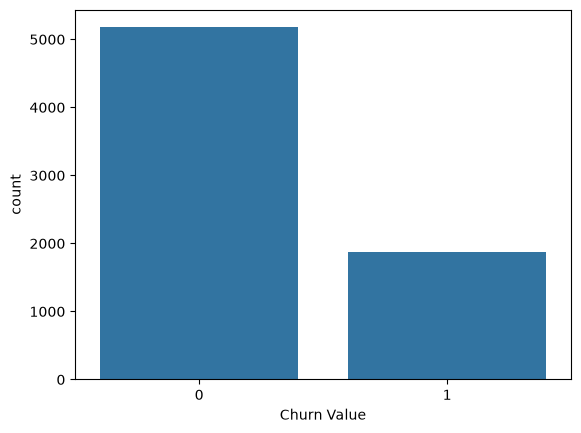

In [59]:
sns.countplot(x='Churn Value', data=df)
plt.show()

## Univariate Analysis

In [67]:
# Numeric variables

numerical_cols = df.select_dtypes(include=['int64','float64']).columns
numerical_cols

Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')

<Axes: xlabel='Monthly Charges', ylabel='Count'>

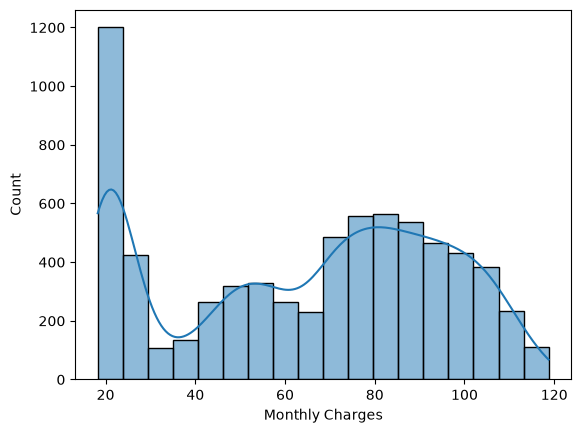

In [70]:
# histogram

sns.histplot(df['Monthly Charges'], kde=True)

<Axes: ylabel='Monthly Charges'>

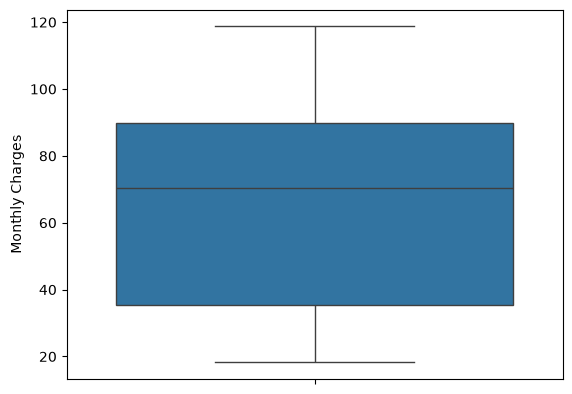

In [71]:
# Box plot

sns.boxplot(df['Monthly Charges'])

## Categorical Variables

In [72]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['CustomerID', 'Country', 'State', 'City', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label',
       'Churn Reason'],
      dtype='object')

<Axes: xlabel='count', ylabel='Contract'>

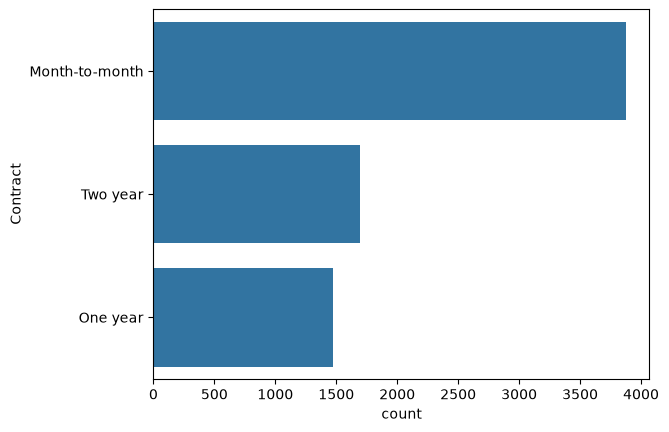

In [73]:
sns.countplot(y=df['Contract'])

## Churn-Based Analysis

Contract vs Churn

In [ ]:
pd.crosstab(df['Contract'],df['Churn Value'],normalize='index')*100

Churn Value,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<Axes: xlabel='Contract', ylabel='count'>

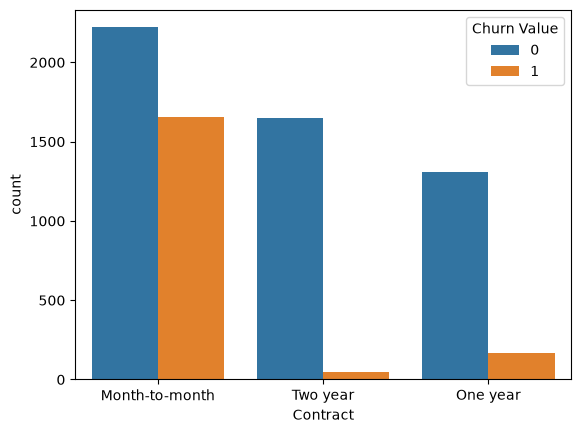

In [79]:
sns.countplot(x='Contract',hue='Churn Value',data=df)

Tenure vs Churn

<Axes: xlabel='Churn Value', ylabel='Tenure Months'>

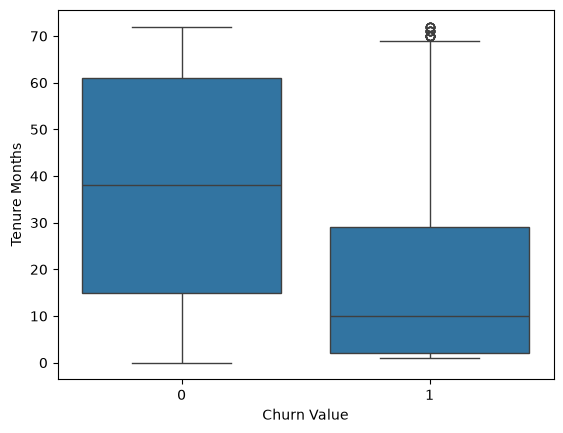

In [83]:
sns.boxplot(x='Churn Value',y='Tenure Months',data=df)

Monthly Charges vs Churn

<Axes: xlabel='Churn Value', ylabel='Monthly Charges'>

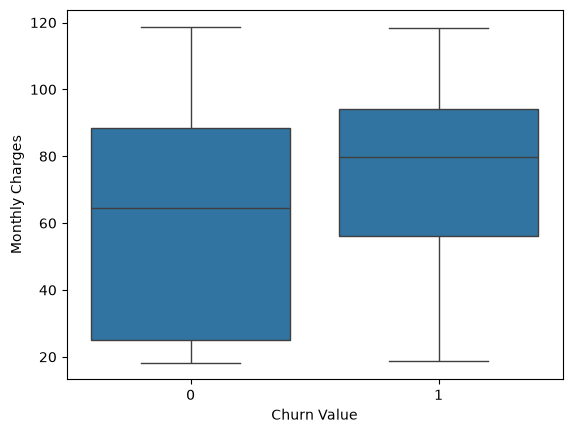

In [84]:
sns.boxplot(x='Churn Value',y='Monthly Charges',data=df)

Payment Method vs Churn

<Axes: xlabel='Payment Method', ylabel='count'>

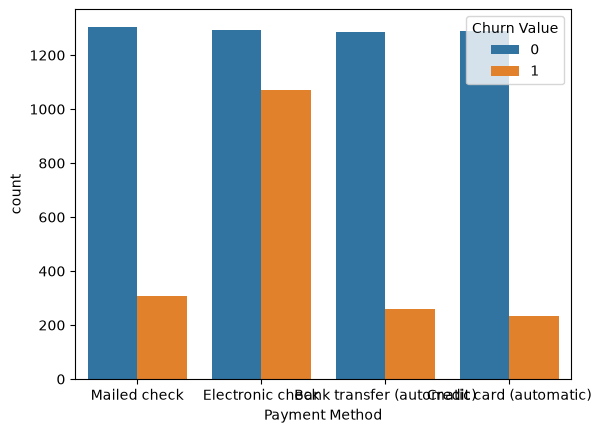

In [86]:
sns.countplot(x='Payment Method',hue='Churn Value',data=df)

Internet Service vs Churn

<Axes: xlabel='Internet Service', ylabel='count'>

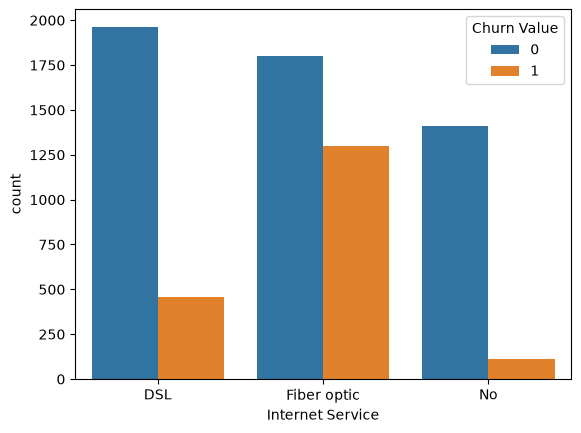

In [88]:
sns.countplot(x='Internet Service',hue='Churn Value',data=df)

Senior Citizen vs Churn

<Axes: xlabel='Senior Citizen', ylabel='count'>

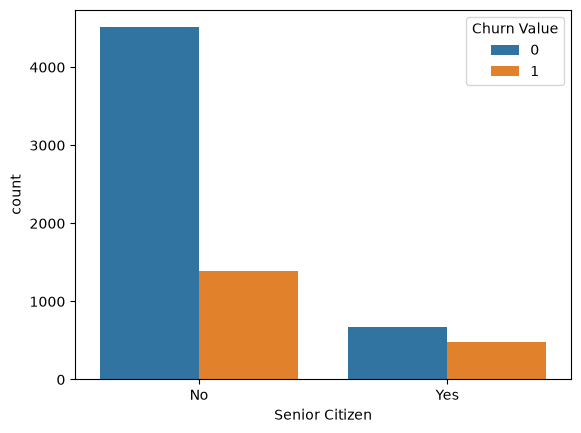

In [90]:
sns.countplot(x='Senior Citizen',hue='Churn Value',data=df)

Churn Score vs Churn

<Axes: xlabel='Churn Value', ylabel='Churn Score'>

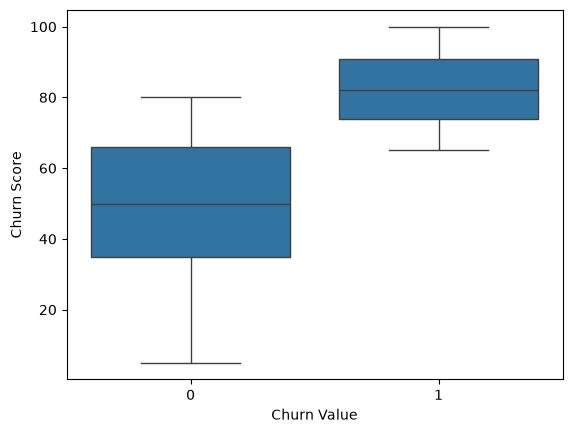

In [108]:
sns.boxplot(x='Churn Value',y='Churn Score',data=df)

Tenure vs Monthly Charges

<Axes: xlabel='Tenure Months', ylabel='Monthly Charges'>

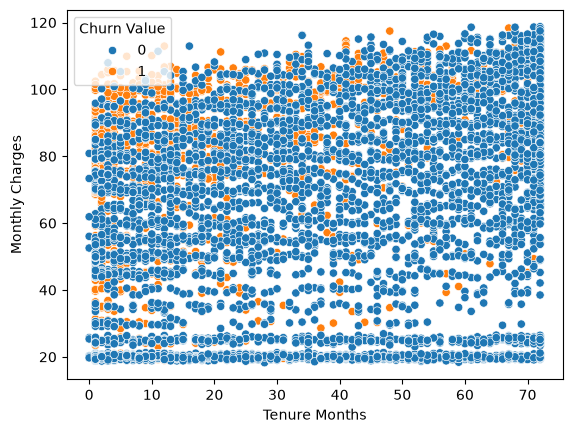

In [109]:
sns.scatterplot(x='Tenure Months',y='Monthly Charges',hue='Churn Value',data=df)

## Correlation Analysis

Numerical relationships.

In [92]:
corr = df.corr(numeric_only=True)
corr

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
Zip Code,1.000000,0.895743,-0.784271,0.001041,-0.004596,-0.001237,0.003346,-0.002769,-0.003562
Latitude,0.895743,1.000000,-0.876779,-0.001632,-0.019899,-0.010168,-0.003384,-0.007684,0.000886
Longitude,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.008977,0.004594,0.004260,0.000485
Tenure Months,0.001041,-0.001632,-0.001678,1.000000,0.247900,0.825464,-0.352229,-0.224987,0.396406
Monthly Charges,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.650864,0.193356,0.133754,0.098693
Total Charges,-0.001237,-0.010168,0.008977,0.825464,0.650864,1.000000,-0.199037,-0.123948,0.341723
Churn Value,0.003346,-0.003384,0.004594,-0.352229,0.193356,-0.199037,1.000000,0.664897,-0.127463
Churn Score,-0.002769,-0.007684,0.004260,-0.224987,0.133754,-0.123948,0.664897,1.000000,-0.079782
CLTV,-0.003562,0.000886,0.000485,0.396406,0.098693,0.341723,-0.127463,-0.079782,1.000000


<Axes: >

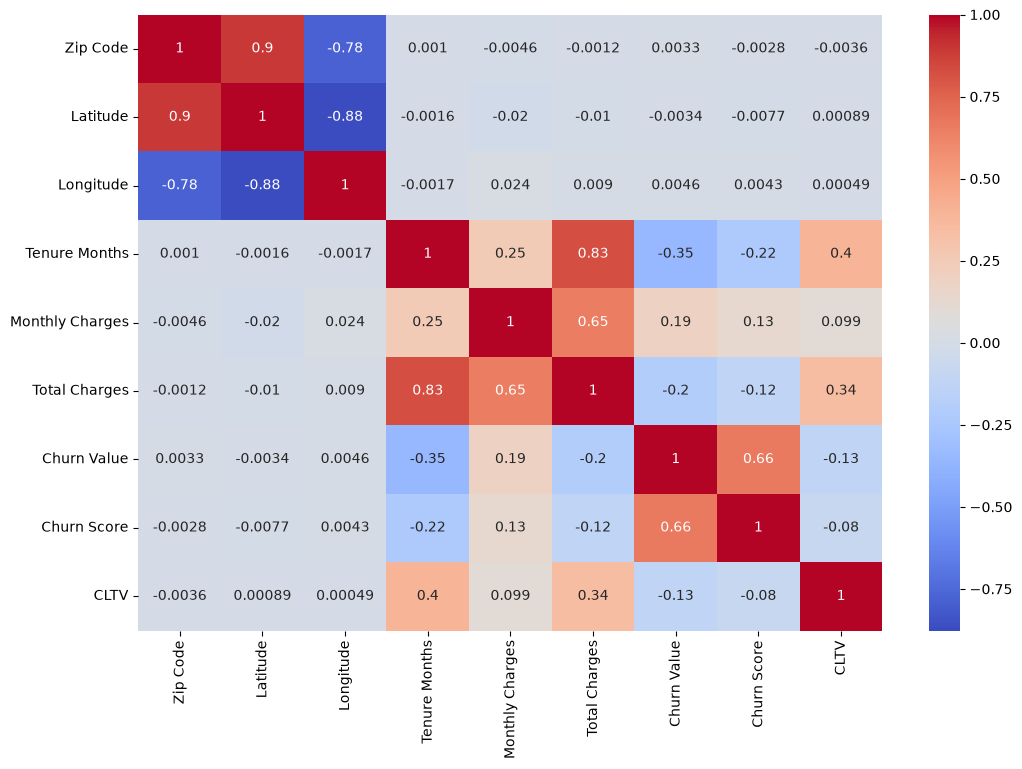

In [93]:
# Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(corr,annot=True,cmap='coolwarm')

## Segment Analysis

In [ ]:
## Segment 1: High Revenue Customers

df.groupby('Churn Value')['Monthly Charges'].mean()

Churn Value
0    61.265124
1    74.441332
Name: Monthly Charges, dtype: float64

In [96]:
## Segment 2: Long-Term Customers

df.groupby('Churn Value')['Tenure Months'].mean()

Churn Value
0    37.569965
1    17.979133
Name: Tenure Months, dtype: float64

In [97]:
## Segment 3: Senior Citizens

pd.crosstab(df['Senior Citizen'],df['Churn Value'],normalize='index')

Churn Value,0,1
Senior Citizen,,
No,0.763938,0.236062
Yes,0.583187,0.416813


In [98]:
## Segment 4: Contract Type

pd.crosstab(df['Contract'],df['Churn Value'],normalize='index')

Churn Value,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [101]:
## Segment 5: Payment Methods

pd.crosstab(df['Payment Method'],df['Churn Value'],normalize='index')

Churn Value,0,1
Payment Method,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


## Outlier Analysis

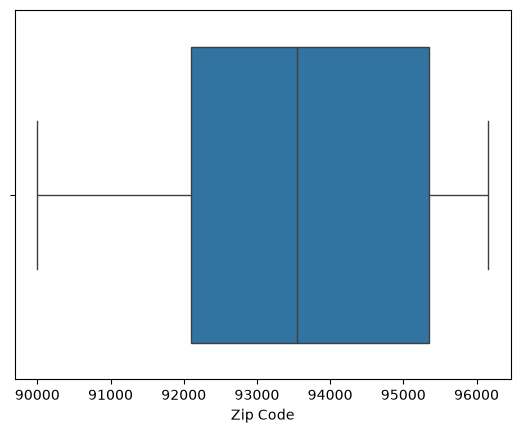

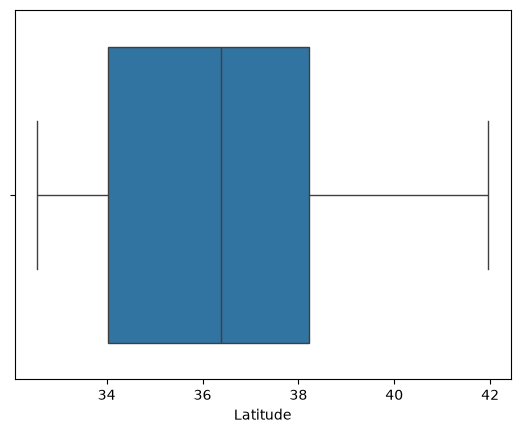

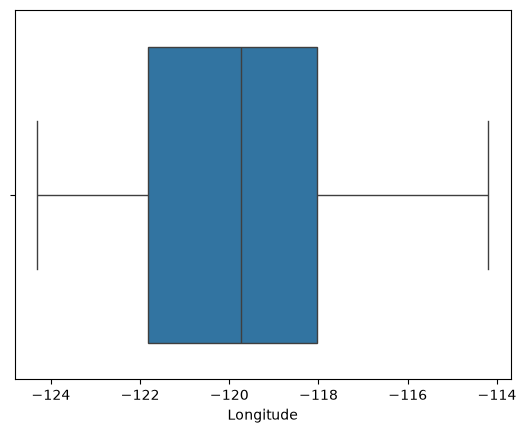

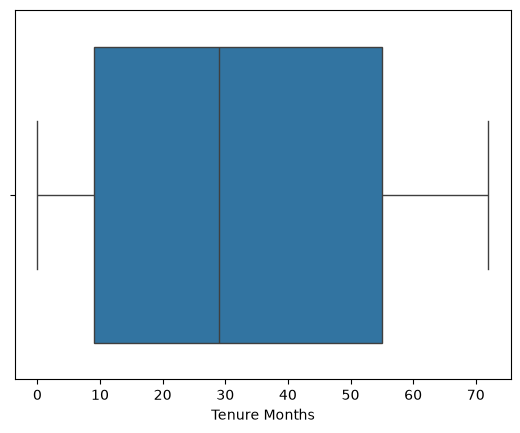

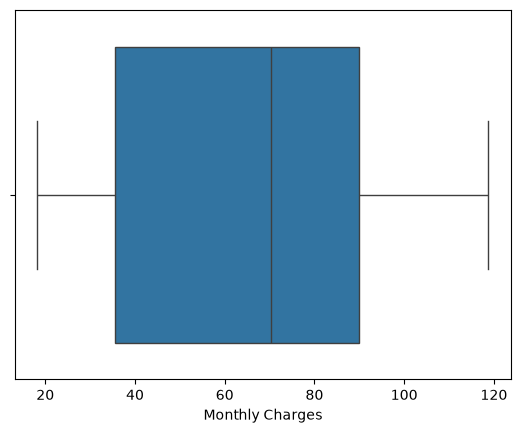

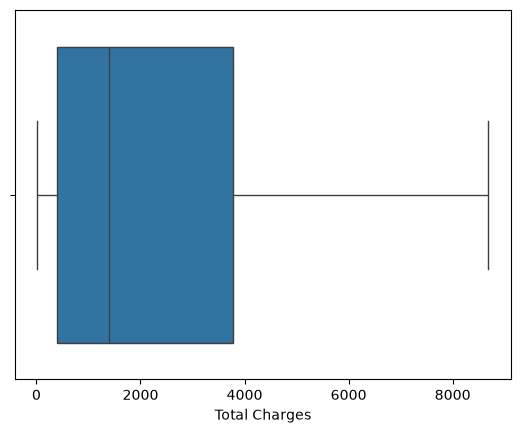

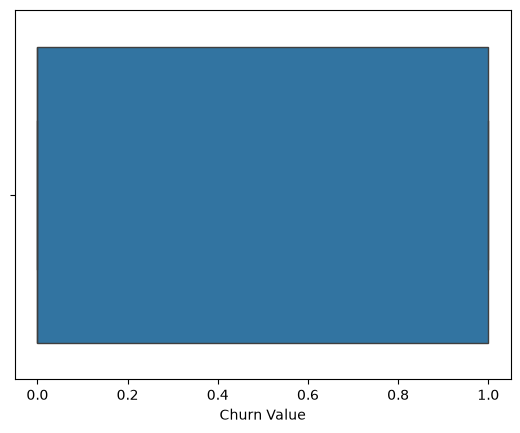

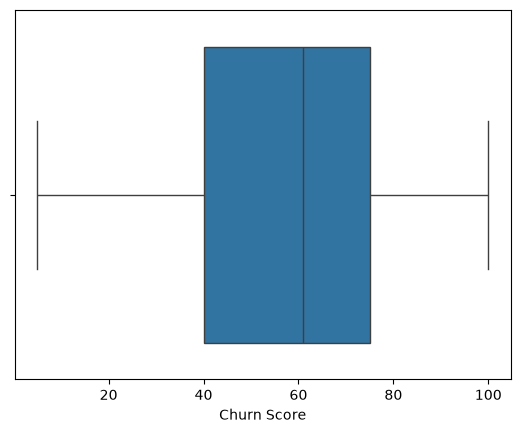

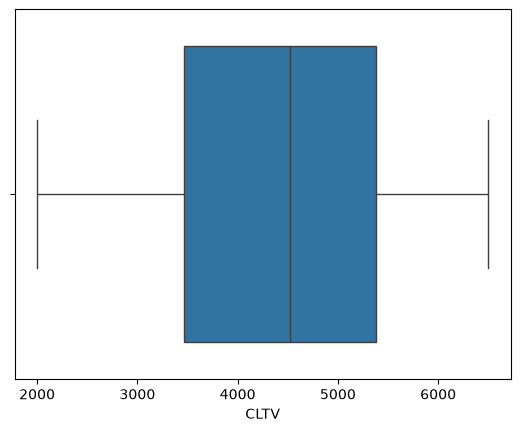

In [106]:
## Check numerical variables.

for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.show()